# Simple Linear Regression Project

## Retail Sales Analysis using Quantity and Sales

**Company:** Walmart (Retail Industry)


## Problem Faced By Company
Walmart and other similar retail companies face issue - **customer demand uncertainty**.   
This is difficult to know how sales will change when customers buy more or less quantity of products.

## Solution For The Problem
We use **Simple Linear Regression** to study and understand the **Relationship Between Quantity and Sales**.
This helps us to understand whether the sales will increase when quantity increases or decrease when quantity decrease.


 ## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

## Load the Dataset
We have load the Supermarket Sales Dataset

In [2]:
df = pd.read_csv("Dataset/SuperMarket Analysis.csv")     ## load the dataset
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [3]:
df.head()       # to show top 5 

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


##  Check Missing Values
We check this dataset have any missing values or not.

In [20]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [4]:
df.isnull().sum()  ## checking missing values

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [5]:
df.columns  # Checking Columns Names

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

##  Selecting The Feature and Target
- **Feature (X):** Quantity
- **Target (y):** Sales

In [6]:
X = df[["Quantity"]]      # independent variable
y = df["Sales"]           # dependent variable

##  Import Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split 

##### We split the dataset into training and testing parts.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)         # Split the data 

##  Import and Create the Model

In [9]:
from sklearn.linear_model import LinearRegression        
model = LinearRegression()

## Train this Linear Regression model 
We use Linear Regression model for predicting the continuous values.

In [10]:
model.fit(X_train, y_train)   

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##  Make Predictions

In [11]:
y_pred = model.predict(X_test)

In [12]:
y_pred[:5]   # viewing the top 5 predicted values

array([348.11436049, 579.688981  , 406.00801562, 174.43339512,
       116.53973999])

In [13]:
y_test[:5]   # viewing the top 5 actual values

521    523.9710
737    616.9800
740    408.7335
660    135.3555
411     45.9270
Name: Sales, dtype: float64

## Importing The Evaluation Metrics
We use MSE and R² score to evaluate model performance

- **MSE (Mean Squared Error):** shows prediction error
- **R² Score:** shows how much model fits


In [14]:
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
mse = mean_squared_error(y_test, y_pred)
mse     # Calculate MSE

32101.07234511716

In [16]:
r2_score = r2_score(y_test, y_pred)
r2_score       # Calculate R2 score

0.5065852654178085

## Step 16: Plotting the Regression Graph

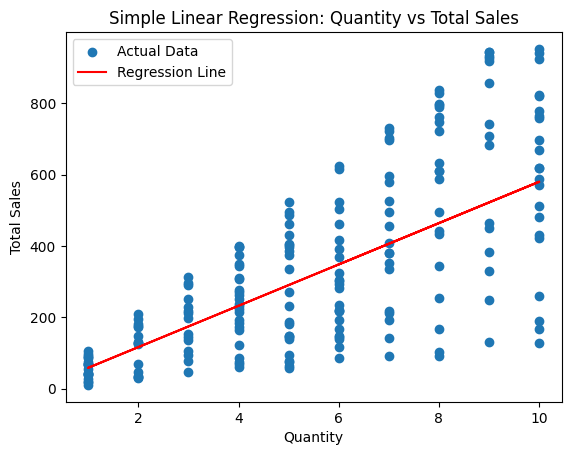

In [17]:
plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_test, y_pred, color="red", label="Regression Line")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.title("Simple Linear Regression: Quantity vs Total Sales")
plt.legend()
plt.show()

This graph visually shows the relationship between Quantity and Sales.   
But not fully dependent on quantity

## Conclusion
- Quantity is used as independent variable and Sales is used as dependent variable.
- The model helps us understand the linear relationship between quantity purchased by customer and sales.

In [22]:
quantity = float(input("Enter the Quantity:"))
input_data = pd.DataFrame([[quantity]])

pred_sales = model.predict(input_data)
print ("Predicted Sales for ", quantity, "is", pred_sales[0])


Enter the Quantity: 3


Predicted Sales for  3.0 is 174.4333951168666


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
